### Step 1.先設定環境, 這版本的EfficientDet使用tensorflow 2.x環境

1. 先把e3上面的程式碼跟資料集上傳到自己的雲端硬碟
2. 掛載Google雲端硬碟
3. 設定Runtime變成GPU

設定訓練資料存放的路徑

In [1]:
folder_path = '/data/'

In [2]:
%ls

 Untitled.ipynb   efficientdet.py                logs/        'output file'/
 __pycache__/     example_EfficientDetb0.ipynb   model_data/   test_cdc/
 data/            font/                          nets/         utils/


### Step 2. 把標註好的資料轉換為訓練用的格式

1. 資料集都存放在data這個目錄內, 
  * Annotations資料夾包含所有的標註檔案
  * ImageSets資料夾存放train.txt, test.txt, 裡面分別為訓練影像與測試影像的檔案名稱
  * JPEGImages資料夾包含所有的影像
2. 我們使用下列的程式碼(由voc_annotation.py修改而來)來產生yolo訓練所需要的檔案
  * 如果使用自己的資料集, 要修改下方的classes變數內容
  * 轉換好的train.txt與test.txt會存放在./data/JPEGImages/的資料夾內

In [3]:
import xml.etree.ElementTree as ET
from os import getcwd

In [4]:
sets=[('train')]

classes = ["aquarium", "bottle", "bowl", "box", "bucket", "plastic_bag", "plate", "styrofoam", 
           "tire", "toilet", "tub", "washing_machine", "water_tower"]

ROOT_DIR = './data/'

def convert_annotation(image_id, list_file):
    in_file = open(ROOT_DIR + 'Annotations/%s.xml'%(image_id),'rb')
    tree=ET.parse(in_file)
    root = tree.getroot()
	
    for obj in root.iter('object'):
        cls = obj.find('name').text
        if cls not in classes:
            continue
        cls_id = classes.index(cls)
        xmlbox = obj.find('bndbox')
        b = (int(xmlbox.find('xmin').text), int(xmlbox.find('ymin').text), int(xmlbox.find('xmax').text), int(xmlbox.find('ymax').text))
        list_file.write(" " + ",".join([str(a) for a in b]) + ',' + str(cls_id))

wd = getcwd()

for image_set in sets:
    print("="*10)
    print('File Source: ', ROOT_DIR + 'ImageSets/%s.txt'%(image_set))    
    print('Export to: ', ROOT_DIR + 'JPEGImages/%s.txt'%(image_set))    
    print("="*10)
    image_ids = open(ROOT_DIR + 'ImageSets/%s.txt'%(image_set)).read().strip().split()
    list_file = open(ROOT_DIR + 'JPEGImages/%s.txt'%(image_set), 'w')
   
    for image_id in image_ids:        
        list_file.write(ROOT_DIR + 'JPEGImages/%s'%(image_id))        
        convert_annotation(image_id[:-4], list_file)
        list_file.write('\n')
    list_file.close()

File Source:  ./data/ImageSets/train.txt
Export to:  ./data/JPEGImages/train.txt


### Step 3. 開始訓練模型

先import所需要的package

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        TensorBoard)
from tensorflow.keras.optimizers import Adam

from nets.efficientdet import Efficientdet
from nets.efficientdet_training import Generator, focal, smooth_l1
from utils.anchors import get_anchors
from utils.utils import BBoxUtility, ModelCheckpoint

In [6]:
def get_classes(classes_path):
    '''loads the classes'''
    with open(classes_path) as f:
        class_names = f.readlines()
    class_names = [c.strip() for c in class_names]
    return class_names

gpus = tf.config.experimental.list_physical_devices(device_type='GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [7]:
# 設定要作為使用的 backbone 的 EfficientNet 網路版本 phi , 跟 model_path 的權重要符合 
phi = 1
freeze_layers = [226, 328, 328, 373, 463, 565, 655, 802]
image_sizes = [512, 640, 768, 896, 1024, 1280, 1408, 1536]

# 設定路徑
model_path = "model_data/efficientdet-d"+ str(phi) + "-voc.h5"
annotation_path = './data/JPEGImages/train.txt'
log_dir = 'logs/000/'               
classes_path = './model_data/my_classes.txt'

class_names = get_classes(classes_path)
print("-------------------CLASS NAMES-------------------")
print(class_names)
print("-------------------CLASS NAMES-------------------")
num_classes = len(class_names)

-------------------CLASS NAMES-------------------
['aquarium', 'bottle', 'bowl', 'box', 'bucket', 'plastic_bag', 'plate', 'styrofoam', 'tire', 'toilet', 'tub', 'washing_machine', 'water_tower']
-------------------CLASS NAMES-------------------


In [8]:
# # load pre-train weight
# model = Efficientdet(phi,num_classes=num_classes)

# model.load_weights(model_path, by_name=True, skip_mismatch=True)

In [9]:
# load pre-train weight
model = Efficientdet(phi,num_classes=num_classes)

model.load_weights("./logs/000/trained_weights_stage_1_phi"+str(phi)+".h5", by_name=True, skip_mismatch=True)

In [10]:
model.summary()

Model: "efficientdet"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 640, 640, 3) 0                                            
__________________________________________________________________________________________________
stem_conv (Conv2D)              (None, 320, 320, 32) 864         input_1[0][0]                    
__________________________________________________________________________________________________
stem_bn (BatchNormalization)    (None, 320, 320, 32) 128         stem_conv[0][0]                  
__________________________________________________________________________________________________
stem_activation (Activation)    (None, 320, 320, 32) 0           stem_bn[0][0]                    
_______________________________________________________________________________________

In [11]:
# 設定訓練參數
logging = TensorBoard(log_dir=log_dir)
checkpoint = ModelCheckpoint(log_dir+'ep{epoch:03d}-loss{loss:.3f}-val_loss{val_loss:.3f}.h5',
    monitor='val_loss', save_weights_only=True, save_best_only=True, period=3)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=1)

#計算先驗框
priors = get_anchors(image_sizes[phi])
bbox_util = BBoxUtility(num_classes, priors)

# 分train/val data
val_split = 0.2
with open(annotation_path) as f:
    lines = f.readlines()
np.random.seed(0)
np.random.shuffle(lines)
num_val = int(len(lines)*val_split)
num_train = len(lines) - num_val

In [12]:
# # Train with frozen layers first, to get a stable loss.
# for i in range(freeze_layers[phi]):
#     model.layers[i].trainable = False
# model.layers[-1].trainable = True    
    
# if True:
#     batch_size = 32
#     Lr = 1e-3
#     Init_Epoch = 0
#     Freeze_Epoch = 50

#     gen = Generator(bbox_util, batch_size, lines[:num_train], lines[num_train:],
#                     (image_sizes[phi], image_sizes[phi]),num_classes)
#     model.compile(loss={
#                 'regression'    : smooth_l1(),
#                 'classification': focal()
#             },optimizer=keras.optimizers.Adam(Lr)
#     )   
#     print('Train on {} samples, val on {} samples, with batch size {}.'.format(num_train, num_val, batch_size))
#     model.fit(
#             gen.generate(True), 
#             steps_per_epoch=max(1, num_train//batch_size),
#             validation_data=gen.generate(True),
#             validation_steps=max(1, num_val//batch_size),
#             epochs=Freeze_Epoch,             
#             initial_epoch=Init_Epoch,
#             verbose=1,
#             callbacks=[logging, checkpoint, reduce_lr, early_stopping]
#         )
    
#     model.save_weights(log_dir + 'trained_weights_stage_1_phi'+str(phi)+'.h5')

In [13]:
# Unfreeze and continue training, to fine-tune.
# Train longer if the result is not good.

for i in range(freeze_layers[phi]):
    model.layers[i].trainable = True
print('Unfreeze all of the layers.')

if True:
    batch_size = 8
    Lr = 1e-4
    Freeze_Epoch = 50
    Epoch = 200
    
    gen = Generator(bbox_util, batch_size, lines[:num_train], lines[num_train:],
                    (image_sizes[phi], image_sizes[phi]),num_classes)

    model.compile(loss={
                'regression'    : smooth_l1(),
                'classification': focal()
            },optimizer=keras.optimizers.Adam(Lr)
    )   
    print('Train on {} samples, val on {} samples, with batch size {}.'.format(num_train, num_val, batch_size))
    model.fit(
            gen.generate(True), 
            steps_per_epoch=max(1, num_train//batch_size),
            validation_data=gen.generate(True),
            validation_steps=max(1, num_val//batch_size),
            epochs=Epoch, 
            verbose=1,
            initial_epoch=Freeze_Epoch,
            callbacks=[logging, checkpoint, reduce_lr, early_stopping]
        )
    model.save_weights(log_dir + 'trained_weights_final.h5')

# Further training if needed.  

Unfreeze all of the layers.
Train on 2137 samples, val on 534 samples, with batch size 8.


/usr/local/lib/python3.6/dist-packages/numpy/core/_asarray.py:136: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order, subok=True)
/usr/local/lib/python3.6/dist-packages/tensorflow/python/keras/utils/generic_utils.py:500: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)


Epoch 51/200
267/267 [==============================] - 197s 659ms/step - loss: 0.4733 - regression_loss: 0.0370 - classification_loss: 0.4362 - val_loss: 0.4017 - val_regression_loss: 0.0345 - val_classification_loss: 0.3672
Epoch 52/200
267/267 [==============================] - 172s 646ms/step - loss: 0.4240 - regression_loss: 0.0354 - classification_loss: 0.3887 - val_loss: 0.3887 - val_regression_loss: 0.0313 - val_classification_loss: 0.3574
Epoch 53/200
267/267 [==============================] - 171s 642ms/step - loss: 0.4048 - regression_loss: 0.0330 - classification_loss: 0.3719 - val_loss: 0.3803 - val_regression_loss: 0.0311 - val_classification_loss: 0.3493
Epoch 54/200
267/267 [==============================] - 171s 641ms/step - loss: 0.3970 - regression_loss: 0.0325 - classification_loss: 0.3645 - val_loss: 0.3585 - val_regression_loss: 0.0296 - val_classification_loss: 0.3289
Epoch 55/200
267/267 [==============================] - 171s 641ms/step - loss: 0.3794 - regress

267/267 [==============================] - 171s 642ms/step - loss: 0.2045 - regression_loss: 0.0230 - classification_loss: 0.1815 - val_loss: 0.1756 - val_regression_loss: 0.0207 - val_classification_loss: 0.1549
Epoch 88/200
267/267 [==============================] - 171s 641ms/step - loss: 0.1984 - regression_loss: 0.0225 - classification_loss: 0.1759 - val_loss: 0.1530 - val_regression_loss: 0.0199 - val_classification_loss: 0.1330
Epoch 89/200
267/267 [==============================] - 172s 644ms/step - loss: 0.1905 - regression_loss: 0.0219 - classification_loss: 0.1686 - val_loss: 0.1662 - val_regression_loss: 0.0211 - val_classification_loss: 0.1450
Epoch 90/200
267/267 [==============================] - 171s 642ms/step - loss: 0.1919 - regression_loss: 0.0225 - classification_loss: 0.1694 - val_loss: 0.1606 - val_regression_loss: 0.0213 - val_classification_loss: 0.1393
Epoch 91/200
267/267 [==============================] - 172s 645ms/step - loss: 0.1828 - regression_loss: 0.0

267/267 [==============================] - 172s 643ms/step - loss: 0.1232 - regression_loss: 0.0183 - classification_loss: 0.1049 - val_loss: 0.0920 - val_regression_loss: 0.0152 - val_classification_loss: 0.0768
Epoch 123/200
267/267 [==============================] - 171s 641ms/step - loss: 0.1161 - regression_loss: 0.0176 - classification_loss: 0.0985 - val_loss: 0.0973 - val_regression_loss: 0.0162 - val_classification_loss: 0.0811
Epoch 124/200
267/267 [==============================] - 171s 642ms/step - loss: 0.1178 - regression_loss: 0.0175 - classification_loss: 0.1002 - val_loss: 0.0985 - val_regression_loss: 0.0159 - val_classification_loss: 0.0826
Epoch 125/200
267/267 [==============================] - 171s 640ms/step - loss: 0.1155 - regression_loss: 0.0175 - classification_loss: 0.0980 - val_loss: 0.0919 - val_regression_loss: 0.0164 - val_classification_loss: 0.0755

Epoch 00125: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
Epoch 126/200
267/267 [==

267/267 [==============================] - 170s 638ms/step - loss: 0.1109 - regression_loss: 0.0171 - classification_loss: 0.0939 - val_loss: 0.0851 - val_regression_loss: 0.0150 - val_classification_loss: 0.0701

Epoch 00156: ReduceLROnPlateau reducing learning rate to 3.906249901319825e-07.
Epoch 157/200
267/267 [==============================] - 171s 641ms/step - loss: 0.1101 - regression_loss: 0.0173 - classification_loss: 0.0928 - val_loss: 0.0840 - val_regression_loss: 0.0147 - val_classification_loss: 0.0692
Epoch 158/200
267/267 [==============================] - 170s 637ms/step - loss: 0.1076 - regression_loss: 0.0173 - classification_loss: 0.0903 - val_loss: 0.0808 - val_regression_loss: 0.0141 - val_classification_loss: 0.0668
Epoch 159/200
267/267 [==============================] - 170s 637ms/step - loss: 0.1011 - regression_loss: 0.0164 - classification_loss: 0.0847 - val_loss: 0.0834 - val_regression_loss: 0.0145 - val_classification_loss: 0.0688

Epoch 00159: ReduceLROnP

### Step 4. 使用訓練完畢的權重來進行預測

In [35]:
import tensorflow as tf
from PIL import Image
from efficientdet import EfficientDet
%matplotlib inline

gpus = tf.config.experimental.list_physical_devices(device_type='GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [36]:
#load model
efficientdet = EfficientDet(model_path="./logs/000/trained_weights_final.h5", phi=phi, confidence=0.05)

./logs/000/trained_weights_final.h5 model, anchors, and classes loaded.


In [37]:
#set path of test image
img = './data/JPEGImages/200801095.jpg'

#load image
image = Image.open(img)
r_image, bboxes, bbox_classes,score = efficientdet.detect_image(image)

b'plastic_bag 0.97' 67 250 352 608
b'plastic_bag 0.93' 413 12 570 217
b'plastic_bag 0.05' 340 145 600 719
total time: 2.9602596759796143


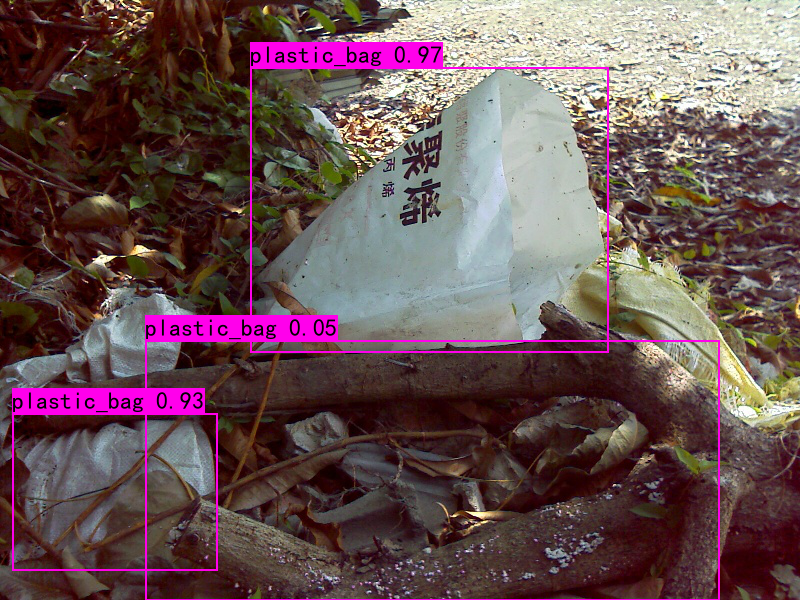

In [38]:
r_image

In [39]:
#set path of test image
img = './test_cdc/test_images/200908261.jpg'

#load image
image = Image.open(img)
r_image = efficientdet.detect_image(image)

b'bottle 0.06' 421 330 451 398
b'tire 0.10' 361 226 423 308
b'water_tower 0.12' 0 0 350 588
b'water_tower 0.06' 104 0 147 29
total time: 0.07448458671569824


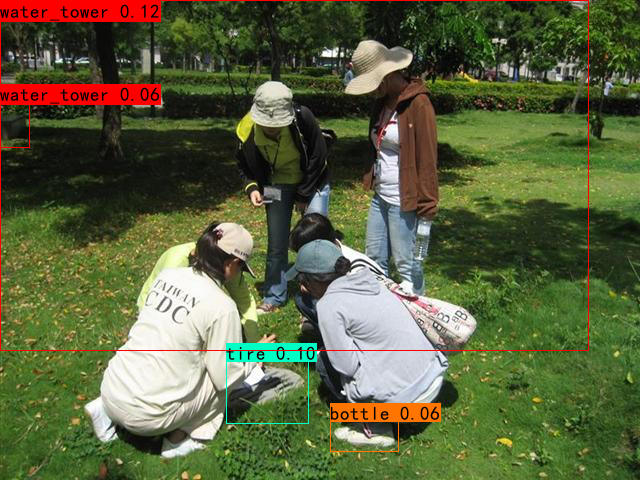

In [40]:
r_image[0]

In [41]:
print(bboxes)
print(bbox_classes)
print(score)

[[ 71.7872901  254.75952402 346.91784811 602.99064889]
 [418.17411147  17.24599225 564.89218437 211.633905  ]
 [345.2618634  149.70910852 605.04956596 713.5983259 ]]
['plastic_bag', 'plastic_bag', 'plastic_bag']
[0.9731487  0.92727572 0.05477324]


In [42]:
#!pip install pandas

In [43]:
import pandas as pd

prediction = pd.DataFrame(columns=['image_filename', 'label_id','x', 'y','w','h', 'confidence'])

In [44]:
prediction

,image_filename,label_id,x,y,w,h,confidence


In [45]:
classes_id = {"aquarium":1, "bottle":2, "bowl":3, "box":4, "bucket":5, "plastic_bag":6, "plate":7, "styrofoam":8, 
           "tire":9, "toilet":10, "tub":11, "washing_machine":12, "water_tower":13}

In [46]:
import os 
import glob
import numpy as np

fail = 0
j  = 0
for image_name in glob.glob("./test_cdc/test_images/*.jpg"):
    print('-'*10)
    print(j, 'th')
    j+=1
    image = Image.open(image_name)
    
    r_image = efficientdet.detect_image(image)
    
    image.close()
    
    if type(r_image) != tuple: 
        fail += 1
        continue
    else:
        bboxes, bbox_classes,score = r_image[1], r_image[2], r_image[3]
    
        for i in range(len(bboxes)):
            row = {
                "image_filename": image_name[23:],
                "label_id":classes_id[bbox_classes[i]], 
                "x":int(max(0, bboxes[i][1])),
                "y":int(max(0, bboxes[i][0])),
                "w":int(bboxes[i][3]-bboxes[i][1]),
                "h":int(bboxes[i][2]-bboxes[i][0]),
                "confidence":score[i]
            }

            prediction = prediction.append(row, ignore_index=True)
    
#     break

----------
0 th
b'bowl 0.60' 79 303 210 400
b'bowl 0.28' 0 140 62 201
b'bowl 0.21' 0 202 117 399
b'bowl 0.07' 35 203 195 342
b'bucket 0.51' 222 229 300 390
b'bucket 0.24' 85 303 237 400
b'bucket 0.11' 6 200 161 313
b'plastic_bag 0.27' 220 224 300 395
b'plastic_bag 0.08' 0 140 86 204
b'plastic_bag 0.06' 95 292 280 400
b'plate 0.18' 0 205 95 400
b'styrofoam 0.09' 0 200 92 400
b'tub 0.06' 0 195 180 400
total time: 0.1086423397064209
----------
1 th
b'bottle 0.06' 421 330 451 398
b'tire 0.10' 361 226 423 308
b'water_tower 0.12' 0 0 350 588
b'water_tower 0.06' 104 0 147 29
total time: 0.06250619888305664
----------
2 th
b'bowl 0.09' 112 0 164 19
b'bucket 0.14' 114 0 189 21
b'plastic_bag 0.67' 90 284 210 400
b'tire 0.99' 98 69 164 176
b'tire 0.95' 51 192 97 281
b'tire 0.90' 90 190 134 273
b'tire 0.79' 115 189 162 273
b'tire 0.63' 135 193 186 281
b'tire 0.46' 163 194 207 283
b'tire 0.40' 77 193 114 279
b'tire 0.19' 111 0 184 21
b'tire 0.07' 0 60 59 400
b'tire 0.07' 0 250 64 400
b'tire 0.06' 8

b'bucket 0.69' 0 0 300 400
b'tire 0.32' 0 4 300 400
b'water_tower 0.07' 16 12 263 370
total time: 0.06264281272888184
----------
20 th
b'bottle 0.06' 103 243 134 280
b'bottle 0.06' 213 82 240 137
b'bowl 0.96' 70 236 113 298
b'bowl 0.92' 0 121 54 193
b'bowl 0.91' 77 58 148 134
b'bowl 0.86' 44 85 100 140
b'bowl 0.86' 67 187 107 233
b'bowl 0.77' 80 130 135 194
b'bowl 0.74' 0 78 49 137
b'bowl 0.66' 132 131 205 201
b'bowl 0.54' 138 224 182 272
b'bowl 0.49' 0 38 31 101
b'bowl 0.32' 173 174 240 272
b'bowl 0.28' 92 205 139 256
b'bowl 0.11' 111 101 151 146
b'bowl 0.09' 68 99 125 171
b'bowl 0.09' 144 193 216 270
b'bowl 0.08' 68 221 88 253
b'bowl 0.08' 75 201 113 266
b'bowl 0.07' 99 240 136 282
b'bowl 0.06' 86 158 137 234
b'bowl 0.05' 23 82 60 136
b'box 0.10' 103 0 240 155
b'bucket 0.70' 132 130 202 204
b'bucket 0.10' 103 58 231 151
b'bucket 0.07' 145 198 219 269
b'bucket 0.05' 184 309 226 320
b'plastic_bag 0.06' 123 0 240 154
b'plate 0.57' 175 175 240 270
b'plate 0.43' 0 38 31 101
b'plate 0.39' 

----------
36 th
b'bottle 0.14' 144 58 277 314
b'bucket 0.18' 143 48 284 320
b'plate 0.06' 137 31 294 332
b'water_tower 0.12' 136 34 291 326
total time: 0.061560630798339844
----------
37 th
b'bowl 0.05' 192 217 212 239
b'bowl 0.05' 0 15 245 400
b'bucket 0.71' 199 275 225 304
b'bucket 0.17' 216 387 250 400
b'bucket 0.11' 58 389 119 400
b'bucket 0.10' 191 214 214 233
b'bucket 0.09' 212 0 300 400
b'bucket 0.08' 208 277 236 306
b'bucket 0.06' 200 268 224 291
b'tire 0.06' 233 0 300 400
b'tire 0.06' 183 177 205 198
b'tire 0.06' 19 389 101 400
b'water_tower 0.06' 81 47 123 69
total time: 0.08343267440795898
----------
38 th
b'bottle 0.27' 98 321 165 411
b'bottle 0.21' 85 139 125 182
b'bottle 0.09' 107 372 161 415
b'bottle 0.08' 158 336 187 379
b'bottle 0.07' 156 0 203 31
b'bottle 0.07' 167 327 224 397
b'bottle 0.05' 125 0 197 13
b'bottle 0.05' 109 389 138 428
b'bowl 0.41' 10 137 55 198
b'bowl 0.21' 85 140 125 181
b'bowl 0.17' 102 328 164 413
b'bowl 0.07' 113 374 162 412
b'box 0.36' 43 116 10

----------
59 th
b'bottle 0.07' 210 133 300 179
b'bottle 0.06' 157 295 213 397
b'bottle 0.05' 116 303 141 338
b'bowl 0.09' 58 63 87 102
b'box 0.37' 164 49 244 148
b'bucket 0.93' 124 219 203 297
b'bucket 0.55' 165 50 245 148
b'plastic_bag 0.68' 0 273 70 363
b'plastic_bag 0.49' 92 81 162 138
b'plastic_bag 0.41' 165 49 245 149
b'plastic_bag 0.32' 55 89 92 124
b'plastic_bag 0.18' 42 121 88 167
b'plastic_bag 0.16' 84 369 142 400
b'plastic_bag 0.14' 58 63 90 108
b'plastic_bag 0.12' 120 73 198 142
b'plastic_bag 0.09' 103 103 167 159
b'plastic_bag 0.07' 78 63 152 116
b'plastic_bag 0.06' 71 116 95 151
b'plastic_bag 0.05' 41 88 89 152
total time: 0.10041928291320801
----------
60 th
b'bottle 0.60' 72 239 198 376
b'bottle 0.11' 164 302 203 365
b'bottle 0.06' 156 31 195 89
b'bowl 0.23' 86 119 143 178
b'bowl 0.06' 69 233 227 372
b'bucket 0.83' 159 40 300 238
b'plate 0.27' 154 28 195 89
b'tire 0.07' 0 0 36 400
total time: 0.05207347869873047
----------
61 th
b'bottle 0.15' 170 134 208 162
b'bottle 0

----------
76 th
b'bucket 0.10' 18 33 266 154
b'plastic_bag 0.06' 219 299 300 400
b'water_tower 0.99' 25 122 300 301
b'water_tower 0.12' 23 29 263 147
total time: 0.06006598472595215
----------
77 th
b'bowl 0.13' 46 123 253 329
b'bowl 0.05' 2 329 194 400
b'box 0.82' 177 0 300 191
b'box 0.08' 178 0 300 69
b'bucket 0.58' 22 80 261 332
b'plate 0.07' 88 101 260 323
total time: 0.07799434661865234
----------
78 th
b'plastic_bag 0.17' 0 6 480 233
b'water_tower 0.05' 113 443 174 491
total time: 0.06900930404663086
----------
79 th
b'bottle 0.07' 18 99 42 118
b'bucket 0.40' 25 75 57 110
b'bucket 0.05' 87 0 130 8
b'plastic_bag 0.43' 0 9 48 83
b'styrofoam 0.06' 15 31 180 240
total time: 0.06350564956665039
----------
80 th
b'bottle 0.06' 238 41 300 93
b'bottle 0.05' 65 422 112 472
b'bottle 0.05' 131 415 165 477
b'bucket 0.16' 161 508 376 640
b'bucket 0.13' 0 0 474 640
b'bucket 0.06' 230 136 407 427
b'plastic_bag 0.09' 119 489 369 634
b'plastic_bag 0.05' 177 162 282 431
b'plate 0.12' 238 125 405 

...

b'bowl 0.90' 248 226 300 297
b'plate 0.35' 13 20 251 400
b'plate 0.13' 241 222 300 294
b'plate 0.08' 220 188 291 245
b'plate 0.05' 272 192 300 240
b'styrofoam 0.51' 18 13 265 400
b'tire 0.09' 263 153 300 202
b'toilet 0.21' 0 15 287 400
total time: 0.10291290283203125
----------
2144 th
b'bottle 0.11' 91 36 118 69
b'bottle 0.06' 167 0 220 32
b'bowl 0.06' 166 0 213 20
b'box 0.14' 91 36 119 68
b'box 0.08' 166 0 227 28
b'bucket 0.14' 166 0 220 25
b'bucket 0.10' 91 36 119 69
b'bucket 0.09' 202 0 293 28
b'bucket 0.08' 115 0 171 8
b'bucket 0.07' 102 153 131 174
b'bucket 0.06' 187 18 300 400
b'plastic_bag 0.16' 167 0 223 21
b'plastic_bag 0.07' 163 0 287 31
b'tire 0.18' 103 83 151 107
b'tire 0.15' 104 102 145 122
b'tire 0.12' 103 108 144 128
b'tire 0.11' 103 153 131 175
b'tire 0.07' 106 91 148 113
b'tire 0.05' 124 98 153 119
b'tire 0.05' 104 128 132 150
b'tire 0.05' 104 116 140 136
total time: 0.09621191024780273
----------
2145 th
b'bucket 0.91' 214 404 344 469
b'bucket 0.58' 249 398 353 439
b

b'bottle 0.24' 224 0 265 17
b'bottle 0.05' 227 0 297 12
b'bowl 0.21' 224 0 266 17
b'bowl 0.14' 132 364 212 400
b'bucket 0.99' 17 118 300 332
b'plastic_bag 0.07' 133 365 205 400
b'plate 0.26' 132 366 213 400
b'plate 0.13' 19 114 95 336
b'toilet 0.17' 133 365 214 400
total time: 0.0831761360168457
----------
2172 th
b'toilet 0.74' 0 43 300 289
b'toilet 0.09' 0 186 257 368
b'tub 0.45' 0 51 300 289
total time: 0.056337594985961914
----------
2173 th
b'box 0.78' 2 21 144 190
b'bucket 0.09' 2 0 144 175
b'washing_machine 0.09' 0 0 140 192
total time: 0.07319831848144531
----------
2174 th
b'bottle 0.21' 105 124 207 174
b'bottle 0.05' 186 0 273 67
b'bowl 0.17' 95 131 272 250
b'bowl 0.14' 104 123 211 174
b'bowl 0.11' 103 154 206 198
b'bowl 0.09' 167 168 255 270
b'bucket 0.18' 143 342 224 400
b'bucket 0.08' 104 124 206 172
b'bucket 0.07' 173 183 269 266
b'plate 0.20' 106 124 207 175
b'plate 0.13' 94 122 255 220
b'plate 0.10' 101 155 206 197
b'plate 0.07' 188 159 271 270
b'toilet 0.79' 112 130 26

----------
2200 th
b'bottle 0.07' 554 366 600 423
b'bottle 0.06' 491 509 546 643
b'bowl 0.08' 431 427 477 530
b'bowl 0.08' 102 0 180 36
b'box 0.12' 533 471 599 574
b'bucket 0.08' 428 415 480 532
b'plastic_bag 0.78' 0 0 480 388
b'plastic_bag 0.75' 512 260 600 379
b'plastic_bag 0.55' 464 142 600 290
b'plastic_bag 0.52' 477 360 546 464
b'plastic_bag 0.44' 502 473 591 643
b'plastic_bag 0.28' 425 480 550 620
b'plastic_bag 0.22' 481 267 539 367
b'plastic_bag 0.15' 479 182 588 457
b'plastic_bag 0.11' 539 183 600 288
b'plastic_bag 0.11' 337 384 573 646
b'plastic_bag 0.09' 0 147 323 665
b'plastic_bag 0.08' 441 370 540 552
b'plastic_bag 0.07' 534 470 600 570
b'plastic_bag 0.07' 0 214 59 325
b'plastic_bag 0.07' 550 348 600 425
b'plastic_bag 0.06' 249 0 488 64
b'plastic_bag 0.06' 434 26 600 389
b'plastic_bag 0.06' 542 145 600 232
b'plastic_bag 0.05' 454 199 536 345
b'plastic_bag 0.05' 417 455 487 579
b'tire 0.54' 0 0 476 388
b'tire 0.26' 228 772 332 800
b'tire 0.11' 101 0 184 37
b'tire 0.06' 0 241

----------
2222 th
b'aquarium 0.08' 77 142 290 348
b'bottle 0.06' 165 364 300 400
b'box 0.13' 53 357 184 400
b'box 0.13' 159 370 300 400
b'box 0.08' 97 91 295 346
b'plastic_bag 0.11' 52 357 183 400
b'plate 0.10' 186 189 284 335
b'styrofoam 0.91' 63 60 262 316
b'styrofoam 0.67' 130 183 285 337
b'styrofoam 0.21' 159 366 300 400
b'styrofoam 0.12' 51 357 184 400
b'styrofoam 0.08' 77 210 220 313
b'styrofoam 0.07' 2 39 34 103
total time: 0.07561826705932617
----------
2223 th
b'bucket 0.07' 38 43 58 68
b'bucket 0.06' 29 0 99 8
b'plastic_bag 0.36' 79 56 104 89
b'plastic_bag 0.10' 38 42 58 67
b'plastic_bag 0.07' 74 60 96 87
b'plastic_bag 0.07' 72 0 117 18
b'plastic_bag 0.07' 33 17 56 53
b'plastic_bag 0.07' 62 43 91 71
b'plastic_bag 0.06' 76 52 101 77
b'water_tower 0.07' 0 0 36 18
total time: 0.0798788070678711
----------
2224 th
b'bottle 0.26' 2 213 80 244
b'bottle 0.09' 173 105 240 133
b'bottle 0.07' 142 217 192 243
b'bottle 0.07' 165 65 222 94
b'bowl 0.06' 141 215 192 241
b'bucket 0.88' 55 2

----------
2237 th
b'bottle 0.11' 59 274 123 362
b'bottle 0.07' 21 343 80 400
b'bottle 0.06' 43 383 91 400
b'bottle 0.06' 207 0 258 11
b'box 0.94' 29 0 255 198
b'bucket 0.99' 104 284 254 400
b'bucket 0.93' 87 177 240 290
b'bucket 0.74' 50 265 174 363
b'bucket 0.26' 72 361 158 400
b'bucket 0.22' 21 347 65 400
b'bucket 0.19' 19 0 265 196
b'bucket 0.12' 33 356 107 400
b'bucket 0.10' 13 312 183 400
b'bucket 0.06' 2 265 83 399
b'bucket 0.06' 57 272 97 344
b'tire 0.07' 5 271 79 395
total time: 0.0626215934753418
----------
2238 th
b'bottle 0.90' 56 129 136 194
b'bottle 0.63' 19 70 123 128
b'bottle 0.40' 0 0 97 46
b'bottle 0.39' 18 107 81 155
b'bottle 0.31' 97 376 156 442
b'bottle 0.11' 91 428 142 448
b'bottle 0.09' 56 86 128 167
b'bucket 0.19' 19 70 124 128
b'bucket 0.12' 19 107 79 156
b'plate 0.20' 94 80 125 128
b'plate 0.08' 47 0 96 46
b'plate 0.05' 28 108 88 155
b'plate 0.05' 93 136 135 192
b'styrofoam 0.77' 39 275 134 395
total time: 0.08693504333496094
----------
2239 th
b'bowl 0.23' 35

In [47]:
print(fail)

17


In [48]:
prediction

,image_filename,label_id,x,y,w,h,confidence
0,201008244.jpg,3,308,83,91,121,0.602726
1,201008244.jpg,3,144,2,50,54,0.283066
2,201008244.jpg,3,207,0,186,112,0.211901
3,201008244.jpg,3,208,40,129,150,0.071258
4,201008244.jpg,5,234,226,150,68,0.510902
...,...,...,...,...,...,...,...
25983,201407027.jpg,5,38,193,175,101,0.073287
25984,201407027.jpg,6,6,25,378,256,0.343130
25985,201407027.jpg,7,3,28,373,260,0.356832
25986,201407027.jpg,8,76,5,319,250,0.162656


In [49]:
prediction.to_csv("./output file/output60_phi"+str(phi)+".csv")

In [29]:
from numpy import asarray
import glob
from PIL import Image

In [30]:
images = []
j = 0
for image_name in glob.glob("./data/JPEGImages/*.jpg"):
    print(j)
    j += 1
    
    image = Image.open(image_name)
    image = asarray(image)
    if(image.shape == (300, 400, 3)):
        #print('fail')
        images.append(image)

#     break

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

1889
1890
1891
1892
1893
1894
1895
1896
1897
1898
1899
1900
1901
1902
1903
1904
1905
1906
1907
1908
1909
1910
1911
1912
1913
1914
1915
1916
1917
1918
1919
1920
1921
1922
1923
1924
1925
1926
1927
1928
1929
1930
1931
1932
1933
1934
1935
1936
1937
1938
1939
1940
1941
1942
1943
1944
1945
1946
1947
1948
1949
1950
1951
1952
1953
1954
1955
1956
1957
1958
1959
1960
1961
1962
1963
1964
1965
1966
1967
1968
1969
1970
1971
1972
1973
1974
1975
1976
1977
1978
1979
1980
1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025
2026
2027
2028
2029
2030
2031
2032
2033
2034
2035
2036
2037
2038
2039
2040
2041
2042
2043
2044
2045
2046
2047
2048
2049
2050
2051
2052
2053
2054
2055
2056
2057
2058
2059
2060
2061
2062
2063
2064
2065
2066
2067
2068
2069
2070
2071
2072
2073
2074
2075
2076
2077
2078
2079
2080
2081
2082
2083
2084
2085
2086
2087
2088


In [31]:
images = np.array(images)
images.shape

(1970, 300, 400, 3)

In [32]:
np.mean(images/255.0, axis=(0,1,2))

array([0.4593257 , 0.46512052, 0.42602176])

In [33]:
np.std(images/255.0, axis=(0,1,2))

array([0.25621281, 0.24830208, 0.26134835])

In [34]:
import tensorflow as tf

tf.test.is_gpu_available()

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


True